# Datapackages

Este notebook demuestra el uso de `datapackages` con brightway25

In [1]:
import bw_processing as bwp
import matrix_utils as mu
import bw2calc as bc
import numpy as np
import seaborn as sb
import pandas as pd

Antes de entrar en materia, pensemos en lo que necesitamos para construir una matriz. ¿Qué datos concretos necesitas? ¿Qué no necesitas?

## Ejercicio

Por favor, piensa en el conjunto mínimo de información que necesitarías para construir una *matriz dispersa* usando [scipy.sparse.coo_matrix](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.coo_matrix.html) (las matrices dispersas sólo almacenan valores distintos de cero). A continuación, crea esta información como matrices Numpy y construye realmente una matriz dispersa.

Esta es la matriz que debes construir:

Traducción realizada con la versión gratuita del traductor DeepL.com

$$\begin{bmatrix} 0 & 1 \\ 2 & 3 \end{bmatrix}$$

## Pista

Necesitarás tres matrices Numpy: una para los datos, otra para los índices de fila y otra para los índices de columna.

## Solución

In [2]:
from scipy import sparse

data = np.array([1, 2, 3])
rows = np.array([0, 1, 1])
cols = np.array([1, 0, 1])

matrix = sparse.coo_matrix((data, (rows, cols)), (2, 2))
matrix.toarray()

array([[0, 1],
       [2, 3]])

## `bw_processing`

Podemos encontrarnos con dificultades cuando queremos almacenar estos datos. La biblioteca `bw_processing` nos ayuda a crear paquetes de datos, que pueden almacenar estos datos de construcción de matrices en una variedad de sistemas de archivos. Puedes leer el [`bw_processing` README](github.com/brightway-lca/bw_processing) para más información, y puedes ver el [PyFilesystem2 Docs](https://docs.pyfilesystem.org/en/latest/) para más información sobre los sistemas de ficheros que se pueden utilizar.

Definamos esta misma matriz en `bw_processing`.

Las matrices por definición son bidimensionales, así que sabemos que para construir matrices siempre necesitaremos especificar los índices de fila y columna de los datos. Combinamos estas dos matrices en una única Numpy [matriz estructurada](https://numpy.org/doc/stable/user/basics.rec.html), que utiliza las etiquetas `row` y `col`.

In [3]:
import bw_processing as bwp
import numpy as np

indices_array = np.array([(0, 1), (1, 0), (1, 1)], dtype=bwp.INDICES_DTYPE)
indices_array

array([(0, 1), (1, 0), (1, 1)], dtype=[('row', '<i8'), ('col', '<i8')])

In [4]:
indices_array['row']

array([0, 1, 1])

In [5]:
bwp.INDICES_DTYPE

[('row', numpy.int64), ('col', numpy.int64)]

El vector (o arreglo o "array") es el mismo:

In [6]:
data_array = np.array([1, 2, 3])
data_array

array([1, 2, 3])

No se necesitan mas elementos para crear un "data package" (o paquete de datos):

In [7]:
dp = bwp.create_datapackage()

dp.add_persistent_vector(
    matrix="some name",
    data_array=data_array,
    name="some name",
    indices_array=indices_array,
)

Hagamos un datapackage más "concreto", para nuestra bicicleta de ejemplo:

<img src='../febrero-3/pictures/simple-graph.png' width='400'>

Necesitamos índices enteros para cada concepto. Los números en sí son arbitrarios, la cuestión es que los utilizaremos de forma coherente en los paquetes de datos y mantendremos una correspondencia entre nuestros conceptos y estos números. Esto podría ser similar a otros conceptos fundamentales como una [base](https://en.wikipedia.org/wiki/Basis_(linear_algebra)).

In [8]:
natural_gas = 101
carbon_fibre = 102
bike = 103
co2 = 201

En nuestra matriz de la tecnosfera, tendremos tres intercambios de producción (cada uno de cantidad 1), y dos intercambios de consumo. Nuestra matriz de biosfera sólo tendrá un número, la emisión de $CO_{2}$ de la producción de fibra de carbono.

Nuestras matrices deberían tener este aspecto

## Matriz de la tecnosfera

Las dimensiones son productos (filas) por actividades (columnas).

$$
\left[\begin{array}{ccc} 
1 & 0 & 0\\
-237 & 1 & 0\\
0 & -2.5 & 1\\
\end{array}\right]
$$

## Matriz de la biosfera

Las dimensiones son flujos (filas) por actividades (columnas).

$$
\left[\begin{array}{ccc} 
0 & 26.6 & 0\\ 
\end{array}\right]
$$ 

## Matriz de caracterización

Las dimensiones son flujos (filas) por flujos (columnas).

$$
\left[\begin{array}{c} 
1\\ 
\end{array}\right]
$$

# Un cálculo ACV inicial

Para utilizar los paquetes de datos, necesitamos saber cuatro cosas de cada punto: los identificadores de fila y columna, el valor del dato y el signo. Sólo necesitamos almacenar los puntos distintos de cero. He aquí un ejemplo para la matriz de la tecnosfera:

In [9]:
t_data = np.array([
    1,   # production of natural gas
    1,   # production of carbon fibre
    1,   # production of bike
    237, # input of natural gas
    2.5, # input of carbon fibre
])
t_indices = np.array([
    (natural_gas, natural_gas), # production of natural gas
    (carbon_fibre, carbon_fibre), # production of carbon fibre
    (bike, bike), # production of bike
    (natural_gas, carbon_fibre), # input of natural gas
    (carbon_fibre, bike), # input of carbon fibre
    ], 
    dtype=bwp.INDICES_DTYPE
)
t_flip = np.array([False, False, False, True, True]) # Numerical sign of the inputs needs to be flipped negative

De manera similar, lo hacemos para las otras matrices (no es necesario cambiar los signos, así que no incluímos el vector `t_flip`.


In [10]:
b_data = np.array([26.6])
b_indices = np.array([
    (co2, carbon_fibre), # emission of CO2
    ], 
    dtype=bwp.INDICES_DTYPE
)

In [11]:
c_data = np.array([1])
c_indices = np.array([
    (co2, co2), # CF of CO2
    ], 
    dtype=bwp.INDICES_DTYPE
)

Ya podemos crear el paquete de datos y agregar los datos de cada matriz al paquete:

In [12]:
dp_static = bwp.create_datapackage()

In [13]:
dp_static.add_persistent_vector(
    matrix='technosphere_matrix',
    indices_array=t_indices,
    data_array=t_data,
    flip_array=t_flip,
)
dp_static.add_persistent_vector(
    matrix='biosphere_matrix',
    indices_array=b_indices,
    data_array=b_data,
)
dp_static.add_persistent_vector(
    matrix='characterization_matrix',
    indices_array=c_indices,
    data_array=c_data,
)

con esto, tenemos un datapackage suficiente para hacer un ACV:

In [14]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static],
)
lca.lci()
lca.lcia()
lca.score

66.50000000000001

## Ejercicio

1. hacer lo mismo par auna bicicleta con acero
2. verificar que el resultado sea coherente


# ACV estocástico

Esto es bastante aburrido hasta ahora. Lo único marginalmente interesante es que podríamos poner nuestro paquete de datos en otro ordenador, y hacer los cálculos en ese ordenador - es decir, estamos listos para los cálculos en la nube. De hecho, la librería `matrix_utils` nos permite especificar paquetes de datos en sitios FTP y almacenamiento en la nube como Amazon S3.

Pero podemos hacer nuestro ejemplo más interesante añadiendo incertidumbre. Para ello, utilizaremos las normas de la biblioteca [stats_arrays](https://stats-arrays.readthedocs.io/en/latest/).

Sólo añadiremos incertidumbre a las entradas, y a la emisión de CO2. Las otras aristas tendrán incertidumbre tipo cero - sin incertidumbre.

In [16]:
t_uncertainty = np.array([
        (0, 1, np.nan, np.nan, np.nan, np.nan, False),
        (0, 1, np.nan, np.nan, np.nan, np.nan, False),    
        (0, 1, np.nan, np.nan, np.nan, np.nan, False),    
        (5, 237, np.nan, np.nan, 200, 300, False), # triangular uncertainty from 200 to 300  
        (5, 2.5, np.nan, np.nan, 2, 3, False), # triangular uncertainty from 2 to 3
    ], 
    dtype=bwp.UNCERTAINTY_DTYPE
)
b_uncertainty = np.array([
        (3, 26.6, 1.5, np.nan, np.nan, np.nan, False), # normal uncertainty with std. dev. of 1.5
    ], 
    dtype=bwp.UNCERTAINTY_DTYPE
)


Ahora podemos crear otro datapackage y usarlo para hacer simulationes MonteCarlo:

In [17]:
dp_stochastic = bwp.create_datapackage()

In [18]:
dp_stochastic.add_persistent_vector(
    matrix='technosphere_matrix',
    indices_array=t_indices,
    data_array=t_data,
    flip_array=t_flip,
    distributions_array=t_uncertainty,
)
dp_stochastic.add_persistent_vector(
    matrix='biosphere_matrix',
    indices_array=b_indices,
    data_array=b_data,
    distributions_array=b_uncertainty,
)
dp_stochastic.add_persistent_vector(
    matrix='characterization_matrix',
    indices_array=c_indices,
    data_array=c_data,
)

In [19]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_stochastic],
    use_distributions=True,
)
lca.lci()
lca.lcia()
    
mc_results = [lca.score for _ in zip(range(50), lca)]

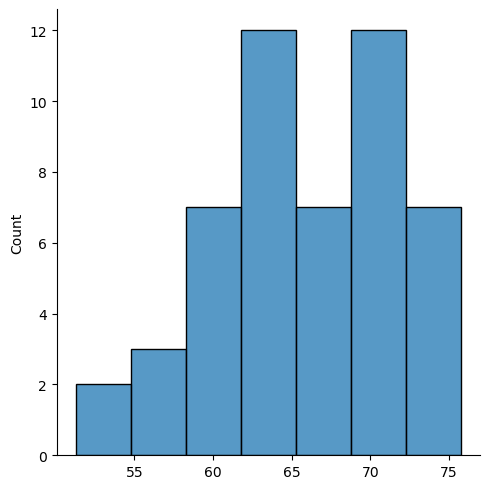

In [20]:
sb.displot(np.array(mc_results))

## Ejercicio

La función numpy para los coeficientes de correlación es `corrcoef`. ¿Podemos hacer un análisis básico de sensibilidad sobre los parámetros de Monte Carlo? Mira a ver si puedes capturar los valores de la matriz durante cada iteración, y luego calcular los coeficientes de correlación entre estos valores de la matriz y las puntuaciones LCIA.

# Correlacionar los intercambios (aristas)

Si muestreamos cada intercambio de forma independiente, perdemos parte de la lógica de nuestro sistema de productos. En nuestro sistema de ejemplo, el $CO_{2}$ debería estar vinculado directamente al consumo de gas natural, pero no es así:

In [22]:
params = []

for _ in range(100):
    next(lca)
    params.append({
        'co2': lca.biosphere_matrix[lca.dicts.biosphere[co2], lca.dicts.activity[carbon_fibre]],
        'ng': -1 * lca.technosphere_matrix[lca.dicts.product[natural_gas], lca.dicts.activity[carbon_fibre]],
    })

<Axes: xlabel='ng', ylabel='co2'>

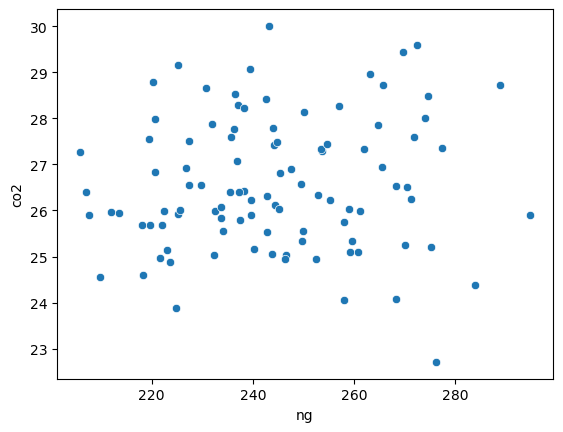

In [23]:
sb.scatterplot(data=pd.DataFrame(params), x='ng', y='co2')

Esto se soluciona extrayendo muestras correlacionadas con antelación: ésta es la idea que subyace en el paquete `presamples`, cuya funcionalidad está ahora integrada directamente en Brightway. Vamos a inventar un modelo para ilustrar cómo funcionaría esto; podemos suponer que (de nuevo, totalmente inventado) el 80% del gas natural se destina a energía, la proporción se mantiene igual, pero con un poco de ruido.

In [24]:
ng_samples = np.random.triangular(200, 237, 300, size=100)
co2_samples = 26.6 / 237 * ng_samples * np.random.normal(loc=1, scale=0.025, size=100)

Ahora podemos añadir otro paquete de datos que sobrescribirá nuestros valores anteriores (pero sólo donde se lo indiquemos). Nótese que ahora estamos creando `arrays`, no `vectors`.

Tenemos que decirle al datapackage que estos dos recursos están correlacionados - de lo contrario habría dos RNGs utilizados para muestrearlos de nuevo de forma independiente. Podemos hacer esto estableciendo `sequential=True` (en cuyo caso empezarían con la columna 0, luego la columna 1, etc.), o utilizando la misma semilla RNG para ambos recursos.

In [25]:
dp_correlated = bwp.create_datapackage(seed=42)

In [26]:
dp_correlated.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(natural_gas, carbon_fibre)], dtype=bwp.INDICES_DTYPE),
    data_array=ng_samples.reshape((1, -1)),
    flip_array=np.array([True]) ,
)
dp_correlated.add_persistent_array(
    matrix='biosphere_matrix',
    indices_array=np.array([(co2, carbon_fibre)], dtype=bwp.INDICES_DTYPE),
    data_array=co2_samples.reshape((1, -1)),
)

Y ahora el uso de nuestras muestras correlacionadas refleja mucho mejor la realidad. Tenga en cuenta que acabamos de añadir el nuevo paquete de datos después de la original, y establecer `use_arrays=True`:

In [27]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_stochastic, dp_correlated],
    use_distributions=True,
    use_arrays=True,
)
lca.lci()
lca.lcia()

corr_params = []

for _ in range(100):
    next(lca)
    corr_params.append({
        'co2': lca.biosphere_matrix[lca.dicts.biosphere[co2], lca.dicts.activity[carbon_fibre]],
        'ng': -1 * lca.technosphere_matrix[lca.dicts.product[natural_gas], lca.dicts.activity[carbon_fibre]],
    })

<Axes: xlabel='ng', ylabel='co2'>

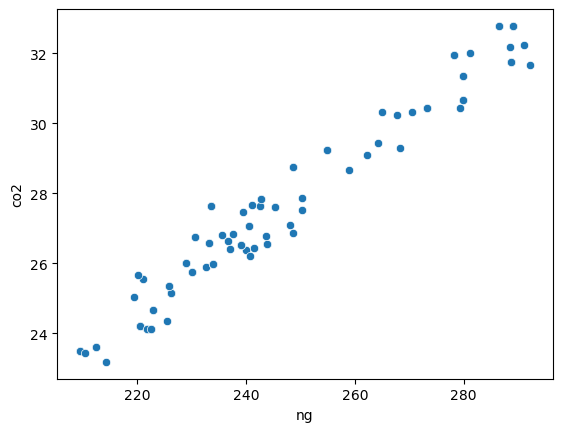

In [28]:
sb.scatterplot(data=pd.DataFrame(corr_params), x='ng', y='co2')

# Utilización de arrays para escenarios

Además de muestras correlacionadas, podemos utilizar matrices para escenarios. Imaginemos dos posibilidades diferentes: una bicicleta ligera con 1,5 kilogramos de fibra de carbono y una plataforma tecnológica que permita compartir bicicletas de forma eficiente, haciendo que cada bicicleta equivalga funcionalmente a dos bicicletas (lo sé, a mí también me parece una tontería). Si tratamos estas posibilidades por separado, tenemos cuatro escenarios en total.

Para que esto funcione, tendremos que crear **dos** nuevas matrices, una para cada opción, y luego decirle al software que haga un muestreo combinatorio:

In [29]:
dp_scenarios = bwp.create_datapackage(combinatorial=True)

In [30]:
dp_scenarios.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(carbon_fibre, bike)], dtype=bwp.INDICES_DTYPE),
    data_array=np.array([(2.5, 1.5)]),
    flip_array=np.array([True]),
    name='cf scenario'
)
dp_scenarios.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(bike, bike)], dtype=bwp.INDICES_DTYPE),
    data_array=np.array([(1, 2)]),
    name='double bike'
)

In [31]:
scenario_mapping = {
    (0, 0): "Original",
    (0, 1): "Each bike counts double",
    (1, 0): "Lightweight",
    (1, 1): "Lightweight & each bike counts double",
}

In [32]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static, dp_scenarios],
    use_arrays=True,
)
lca.lci()
lca.lcia()

In [33]:
resource_group = next(grp for grp in lca.technosphere_mm.groups if grp.label == 'double bike').indexer.indexer

In [34]:
print(lca.score, scenario_mapping[resource_group.index])

for scenario_result in lca:
    print(lca.score, scenario_mapping[resource_group.index])

66.50000000000001 Original
33.25000000000001 Each bike counts double
39.900000000000006 Lightweight
19.950000000000003 Lightweight & each bike counts double


## Ejercicio

¿Puedes construir una bicicleta mitad de acero, mitad de fibra de carbono? ¿Puedes construir escenarios para variar los porcentajes (digamos, tres escenarios)?

# Interfaces

We can add some electricity consumption to the bike manufacturing process, and demonstrate how an `Interface` should work. For our example interface, we can use the Danish company Energinet's [API for the 5 minute interval CO2 intensity of Danish electricity](https://www.energidataservice.dk/tso-electricity/co2emis):

In [35]:
import requests

class DenmarkCO2Interface:
    size = (1,)

    def __next__(self):
        # Supposed to work with ISO 8601 but T intervals raise error...
        URL = "https://api.energidataservice.dk/dataset/co2emis?start=now-P1D&end=now"
        print("Querying energidataservice.dk API")
        result = requests.get(URL).json()['records'][0]['CO2Emission']
        return np.array([result]) / 1000 # g to kg

Eso era sólo la intensidad de CO2, también tenemos que añadir un nodo para el consumo de electricidad. Le daremos el ID `104`, y utilizaremos 100 kilovatios hora (demasiado alto, lo sé).

In [36]:
electricity = 104

In [37]:
dk_elec_dp = bwp.create_datapackage()

In [38]:
dk_elec_dp.add_persistent_vector(
    matrix='technosphere_matrix',
    indices_array=np.array([
            (electricity, electricity), # production of electricity
            (electricity, bike), # use of electricity in bike production
        ], 
        dtype=bwp.INDICES_DTYPE
    ),
    data_array=np.array([1, 100]),
    flip_array=np.array([False, True]),
)

Ahora podemos añadir nuestra interfaz. No estamos añadiendo datos `persistent`, sino datos `dynamic`:

In [39]:
dk_elec_dp.add_dynamic_vector(
    matrix='biosphere_matrix',
    interface=DenmarkCO2Interface(),
    indices_array=np.array([(co2, electricity)], dtype=bwp.INDICES_DTYPE),
)

Como antes, basta con sumar los paquetes de datos:

In [40]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static, dk_elec_dp],
)
lca.lci()
lca.lcia()
lca.score

Querying energidataservice.dk API


78.30000000000001

This is the value we got for CO2 intensity (in kg CO2-eq/kwh):

In [41]:
lca.biosphere_matrix[0, lca.dicts.activity[104]]

np.float64(0.118)

Otros países también tienen API similares, por ejemplo Francia:

<div class="alert alert-block alert-warning">
    The Interface below includes a parameter <code>verify=False</code> in the call to the <code>requests</code> library to pull the data.
    
    
The TLS configuration from www.rte-france.com is incomplete, but the certificates are valid. You can verify the validity by pointing your browser to the <a href=«https://www.rte-france.com/themes/swi/xml/power-co2-emission-fr.xml»> API URL</a> <strong>. 
    We can safely use requests with: </strong> <code>"verify=False"</code>, but the <code>requests</code> library will still warn us about this.
    
More details on this at https://github.com/Depart-de-Sentier/try_brightway_dev/issues/3

</div>

In [42]:
from time import time
import xml.etree.ElementTree as ET

class FranceCO2Interface:
    size = (1,)
    
    def __next__(self):
        # Note: has timestamp but seems to always give latest data
        URL_TEMPLATE = "https://www.rte-france.com/themes/swi/xml/power-co2-emission-fr.xml?_={}"
        print("Querying RTE Eco2mix interface")
        URL = URL_TEMPLATE.format(int(time()))
        # the TLS configuration from www.rte-france.com is incomplete, but the certificates are valid.
        # To verify the validity, point your browser to the URL
        # so, we can safely use requests with "verify=False"
        # see issue on the repo of this notebook -> https://github.com/Depart-de-Sentier/try_brightway_dev/issues/3
        # requests will still warn us about this.
        resp = requests.get(URL, verify=False)        
        root = ET.fromstring(resp.text)
        return np.array([[float(child.text) for child in root.iter('valeur')][-1]]) / 1000 # g to kg

In [43]:
fr_elec_dp = bwp.create_datapackage()

fr_elec_dp.add_persistent_vector(
    matrix='technosphere_matrix',
    indices_array=np.array([
            (electricity, electricity), # production of electricity
            (electricity, bike), # use of electricity in bike production
        ], 
        dtype=bwp.INDICES_DTYPE
    ),
    data_array=np.array([1, 100]),
    flip_array=np.array([False, True]),
)

fr_elec_dp.add_dynamic_vector(
    matrix='biosphere_matrix',
    interface=FranceCO2Interface(),
    indices_array=np.array([(co2, electricity)], dtype=bwp.INDICES_DTYPE),
)

Como antes, podemos agregar simplemente los data packages juntos:

In [44]:
lca = bc.LCA(
    demand={bike: 1},
    data_objs=[dp_static, fr_elec_dp],
)
lca.lci()
lca.lcia()
lca.score

Querying RTE Eco2mix interface


/home/tomas/miniforge3/envs/peru25/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.rte-france.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


72.00000000000001

Este es el valor que obtenemos para la intensidad de CO2 (en kg de CO2-eq/kWh):

In [45]:
lca.biosphere_matrix[0, lca.dicts.activity[electricity]]

np.float64(0.055)

## Ejercicio de clase

¿Cómo modelaríamos un sistema en el que pudiéramos elegir entre la electricidad danesa y la francesa como dos escenarios?